In [85]:
import importlib

import exp_utils
import plot_utils
import graph_utils
import gen_plot_data

importlib.reload(exp_utils)
importlib.reload(plot_utils)
importlib.reload(graph_utils)
importlib.reload(gen_plot_data)

from exp_utils import process_experiments_nebula, prepare_nebula_event_throughput_data, prepare_sink_latency_ecdf_data, prepare_throughput_boxplot_summary
from plot_utils import ecdf_latency_plot, event_throughput_boxplot
from gen_plot_data import gen_boxplot_summary_data
import seaborn as sns
from gen_plot_data import gen_ecdf_data

sns.set_theme()

# GPU imputation performance

Average time spent in each recorded pipeline step across the imputation runs.

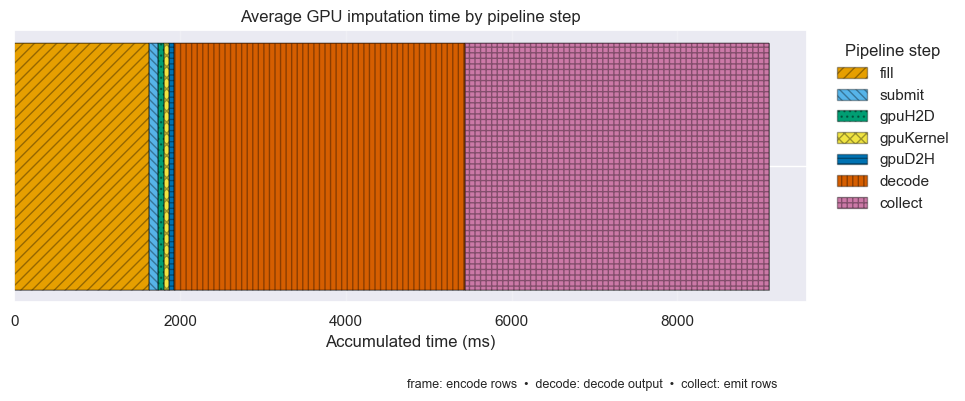

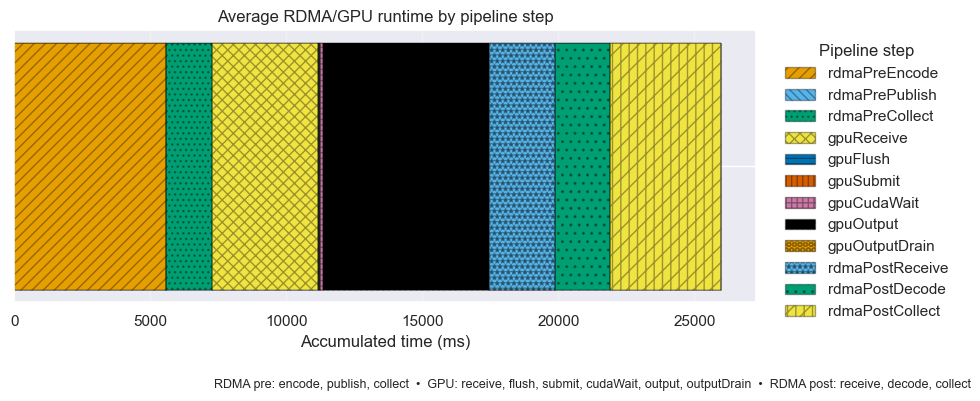

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Average RDMA/GPU runtime by pipeline step'}, xlabel='Accumulated time (ms)'>)

In [105]:
plot_utils.imputation_perf_plot("q1_direct_gpu", percentage=False)
plot_utils.rdma_gpu_perf_plot("q1_rdma_gpu", percentage=False)

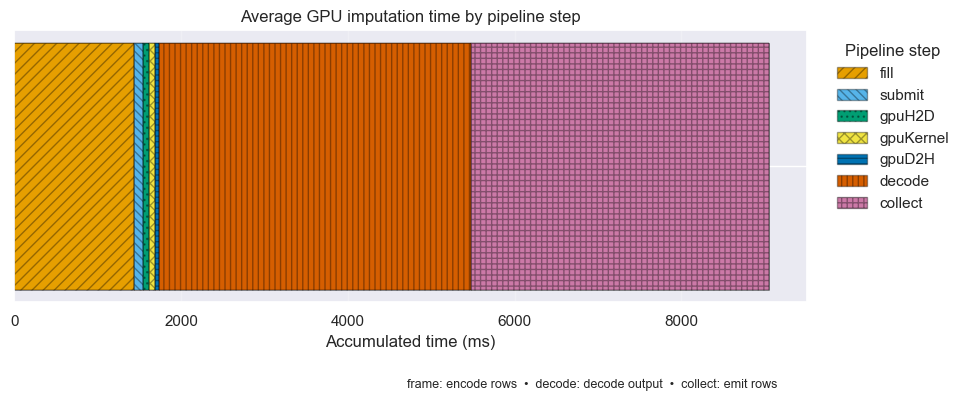

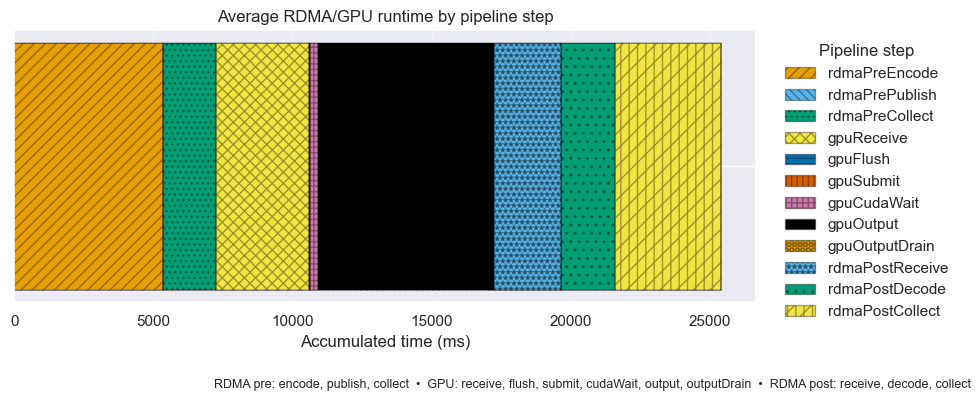

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Average RDMA/GPU runtime by pipeline step'}, xlabel='Accumulated time (ms)'>)

In [99]:
plot_utils.imputation_perf_plot("q1s_direct_gpu", percentage=False)
plot_utils.rdma_gpu_perf_plot("q1s_rdma_gpu", percentage=False)

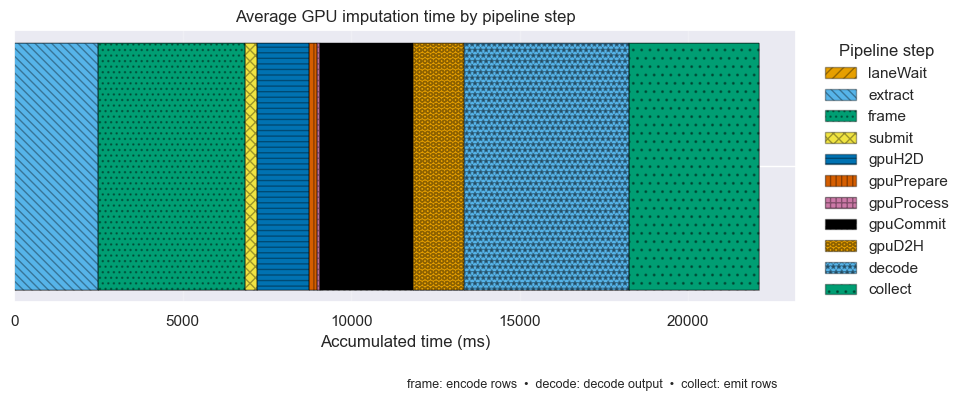

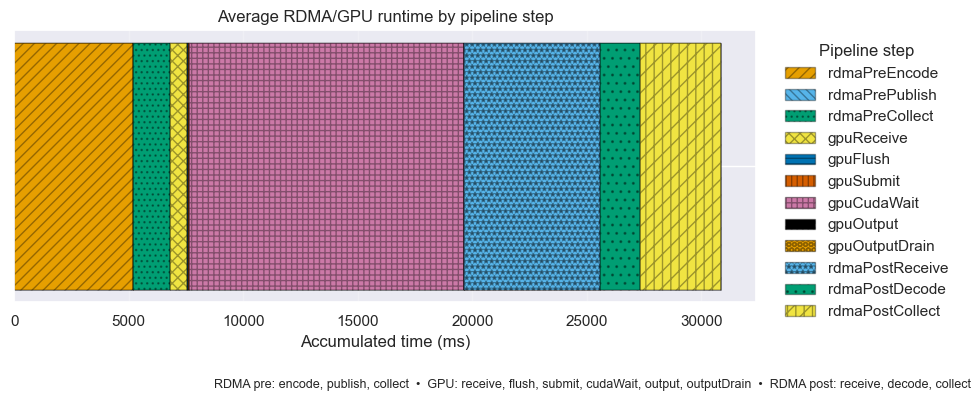

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Average RDMA/GPU runtime by pipeline step'}, xlabel='Accumulated time (ms)'>)

In [100]:
plot_utils.imputation_perf_plot("q1i_direct_gpu", percentage=False)
plot_utils.rdma_gpu_perf_plot("q1i_rdma_gpu", percentage=False)

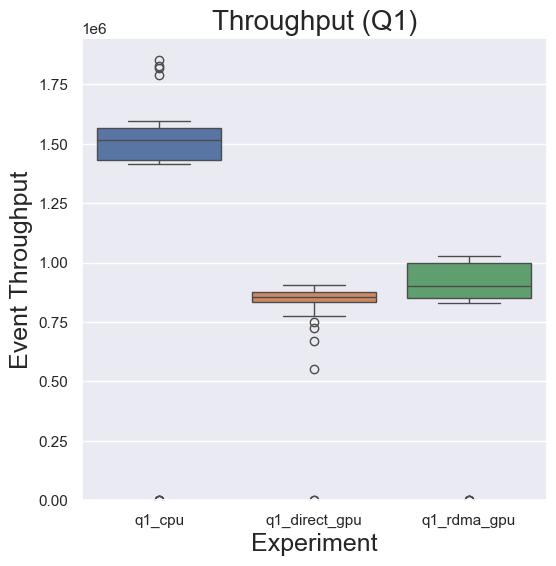

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


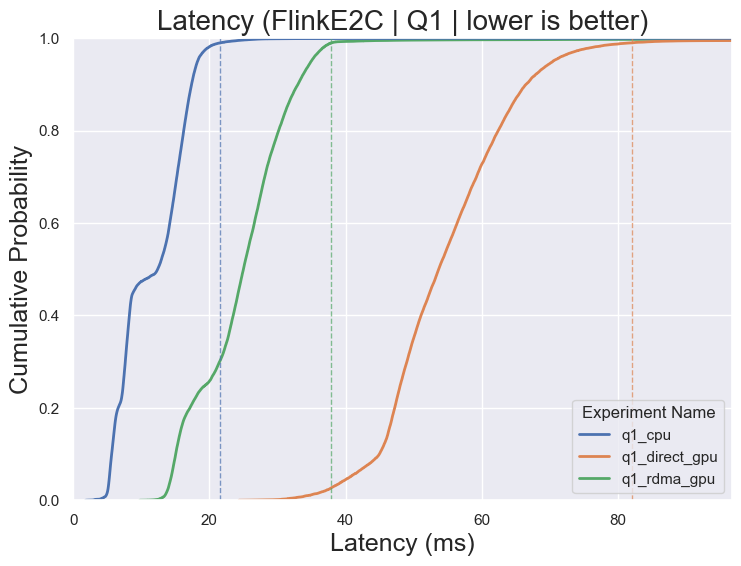

In [94]:
names = ["q1_cpu", "q1_direct_gpu", "q1_rdma_gpu"]
data = process_experiments_nebula(path="data_gpu", names=names)
event_data = prepare_nebula_event_throughput_data(data)
ecdf_lat_df = prepare_sink_latency_ecdf_data("data_gpu", names=names, unit="ms", relative=False)
tput_boxplot_data = prepare_throughput_boxplot_summary("data_gpu", names=names)

# event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1)", hue="exp_name", legend=False)
# plt.savefig("figs/flinke2c_dyn.pdf")
plt.show()

ecdf_latency_plot(
    ecdf_lat_df,
    title="Latency (FlinkE2C | Q1 | lower is better)",
    x_name="Latency (ms)",
    percentiles=(99,),
    clip_percentile=99.5,
)
# plt.savefig("figs/dyn_q1i10_lat_ecdf.pdf")
plt.show()
gen_ecdf_data(
    ecdf_lat_df,
    "dyn_lat",
    output_suffix="paper",
    x_label="Latency (ms)",
    max_points=400,
    uniform=True,
    keep_quantiles=[99],
    clip_percentile=99.5,
    marker_percentiles=[99],
)

# gen_boxplot_summary_data(
#     tput_boxplot_data,
#     "dyn_q1i10_tput",
#     output_suffix="paper",
#     x_col="exp_name",
#     include_outliers=True,
# )

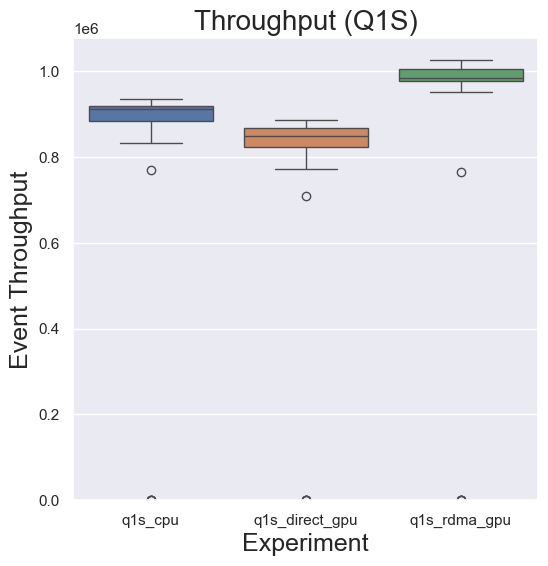

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


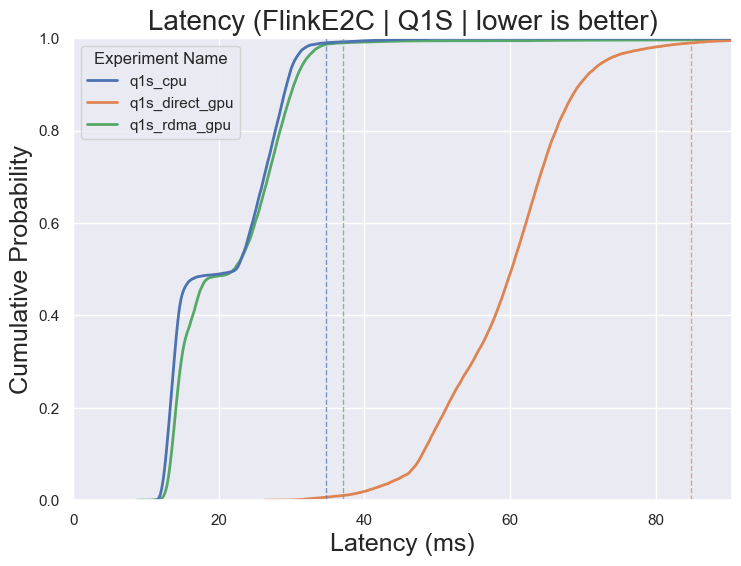

In [101]:
names = ["q1s_cpu", "q1s_direct_gpu", "q1s_rdma_gpu"]
data = process_experiments_nebula(path="data_gpu", names=names)
event_data = prepare_nebula_event_throughput_data(data)
ecdf_lat_df = prepare_sink_latency_ecdf_data("data_gpu", names=names, unit="ms", relative=False)
tput_boxplot_data = prepare_throughput_boxplot_summary("data_gpu", names=names)

# event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1S)", hue="exp_name", legend=False)
# plt.savefig("figs/flinke2c_dyn.pdf")
plt.show()

ecdf_latency_plot(
    ecdf_lat_df,
    title="Latency (FlinkE2C | Q1S | lower is better)",
    x_name="Latency (ms)",
    percentiles=(99,),
    clip_percentile=99.5,
)
# plt.savefig("figs/dyn_q1i10_lat_ecdf.pdf")
plt.show()
gen_ecdf_data(
    ecdf_lat_df,
    "dyn_lat",
    output_suffix="paper",
    x_label="Latency (ms)",
    max_points=400,
    uniform=True,
    keep_quantiles=[99],
    clip_percentile=99.5,
    marker_percentiles=[99],
)

# gen_boxplot_summary_data(
#     tput_boxplot_data,
#     "dyn_q1i10_tput",
#     output_suffix="paper",
#     x_col="exp_name",
#     include_outliers=True,
# )

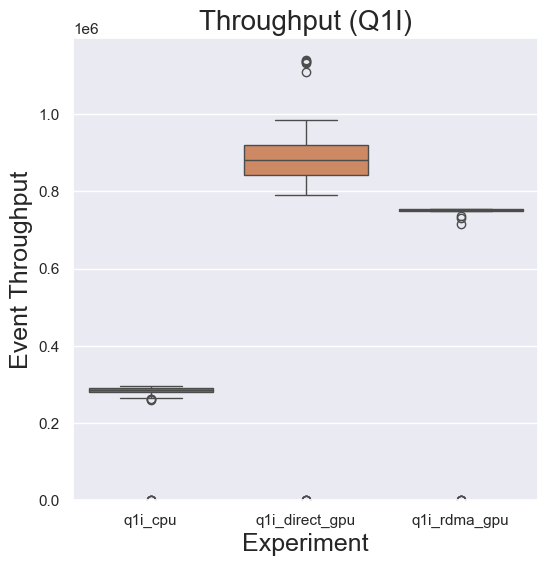

/Users/max/dev/work/stream-exp-viz/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


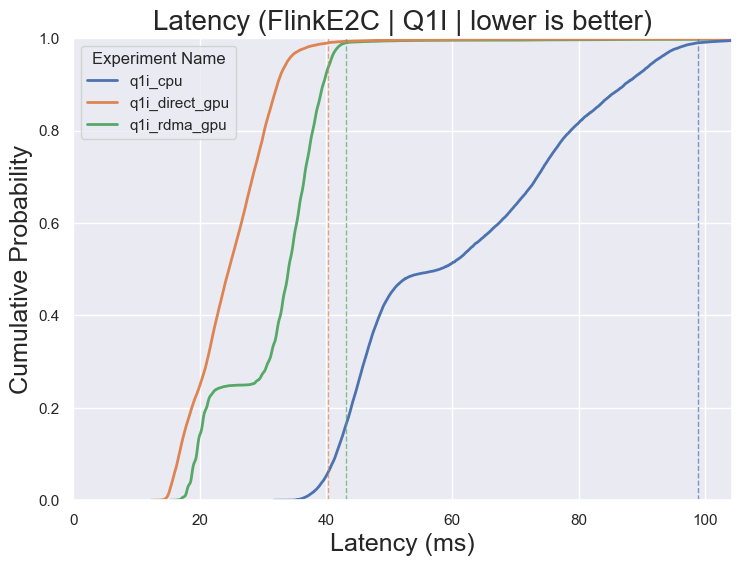

In [98]:
names = ["q1i_cpu", "q1i_direct_gpu", "q1i_rdma_gpu"]
data = process_experiments_nebula(path="data_gpu", names=names)
event_data = prepare_nebula_event_throughput_data(data)
ecdf_lat_df = prepare_sink_latency_ecdf_data("data_gpu", names=names, unit="ms", relative=False)
tput_boxplot_data = prepare_throughput_boxplot_summary("data_gpu", names=names)

# event_throughput_line_plot(event_data, x_name="Relative Throughput", title="Throughput (Serverless | higher is better)", hue="exp_name")
event_throughput_boxplot(event_data, x="exp_name", x_name="Experiment", title="Throughput (Q1I)", hue="exp_name", legend=False)
# plt.savefig("figs/flinke2c_dyn.pdf")
plt.show()

ecdf_latency_plot(
    ecdf_lat_df,
    title="Latency (FlinkE2C | Q1I | lower is better)",
    x_name="Latency (ms)",
    percentiles=(99,),
    clip_percentile=99.5,
)
# plt.savefig("figs/dyn_q1i10_lat_ecdf.pdf")
plt.show()
gen_ecdf_data(
    ecdf_lat_df,
    "dyn_lat",
    output_suffix="paper",
    x_label="Latency (ms)",
    max_points=400,
    uniform=True,
    keep_quantiles=[99],
    clip_percentile=99.5,
    marker_percentiles=[99],
)

# gen_boxplot_summary_data(
#     tput_boxplot_data,
#     "dyn_q1i10_tput",
#     output_suffix="paper",
#     x_col="exp_name",
#     include_outliers=True,
# )